<a href="https://colab.research.google.com/github/AlgoAddict-all-about-data/Articles/blob/master/6_Customer_segmentation/1_Customer_segmentation_and_recommendation_with_RFM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.gridspec as gridspec
from collections import Counter
import plotly.graph_objects as go
from tabulate import tabulate

# display seting
plt.style.use('ggplot')

# 1. Load data

In [5]:
ori_data = pd.read_csv("data.csv", encoding = "ISO-8859-1")
data = ori_data.copy()
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 2. Inititial Data Analysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62551 entries, 0 to 62550
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    62551 non-null  object 
 1   StockCode    62551 non-null  object 
 2   Description  62388 non-null  object 
 3   Quantity     62551 non-null  int64  
 4   InvoiceDate  62551 non-null  object 
 5   UnitPrice    62551 non-null  float64
 6   CustomerID   38501 non-null  float64
 7   Country      62550 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.8+ MB


1. there are missing values in the Description and CustomerID columns which need to be addressed.
2. The InvoiceDate column is already in datetime format
3. A single customer can have multiple transactions as inferred from the repeated CustomerID in the initial rows.

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,62551.0,8.352017,423.334622,-74215.0,1.00,2.00,8.00,74215.00
UnitPrice,62551.0,5.917935,149.003900,0.0,1.25,2.51,4.25,16888.02
CustomerID,38501.0,15387.412379,1765.391847,12346.0,13984.00,15358.00,17017.00,18283.00


In [ ]:
data.describe(include = "object").T

,count,unique,top,freq
InvoiceNo,62551,2787,537434,675
StockCode,62551,2959,85123A,340
Description,62388,2898,WHITE HANGING HEART T-LIGHT HOLDER,345
InvoiceDate,62551,2481,12/6/2010 16:57,675
Country,62550,24,United Kingdom,58579


# 3. Data Cleaning and Transformation

3.1 Handling missing values

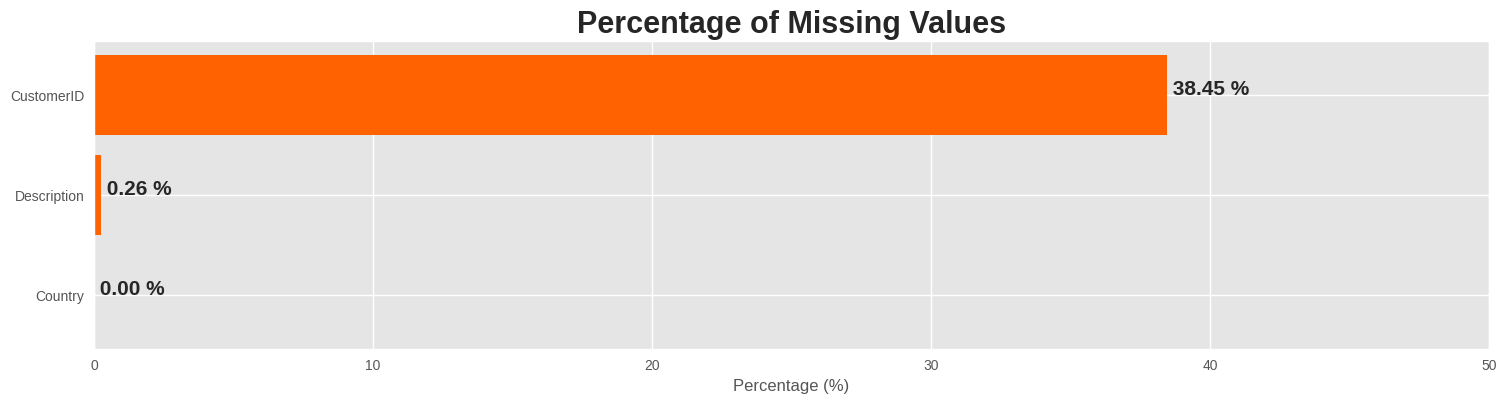

In [ ]:
# Calculating the percentage of missing values for each column
missing_data = data.isnull().sum()
missing_percent = missing_data[missing_data > 0]/data.shape[0] * 100

missing_percent.sort_values(ascending= True, inplace = True)

# Plot
fig, ax = plt.subplots(figsize = (18,4))
ax.barh(missing_percent.index, missing_percent, color='#ff6200')

for i, (value, name) in enumerate(zip(missing_percent, missing_percent.index)):
    #ax.text(value, i, value)
    ax.text(value, i, f"{value: .2f} %", fontweight = "bold", fontsize = 15)

ax.set_xlim([0,50])

plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel("Percentage (%)")
plt.show()

In [ ]:
# Data cleansing

# Locate missing value locations
data[data.CustomerID.isnull()].head()
data[data.Description.isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [ ]:
data = data.dropna(subset = ['Description', 'CustomerID'])

In [ ]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## 3.2 Handling duplications

In [ ]:
# Find duplicate rows
dup_rows = data[data.duplicated(keep= False)]

# sort value
dup_rows_sorted = dup_rows.sort_values(by= ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])
#dup_rows_sorted.head(10)

In [ ]:
# drop duplication
print(f"Data set has {data.shape[0]} rows before removing")
data.drop_duplicates(inplace = True)
print(f"Data set has {data.shape[0]} rows after removing")

Data set has 38501 rows before removing
Data set has 37887 rows after removing


## 3.3 Handling canceling orders



In [ ]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Example of canceled order
data[data.Quantity == -80995.00]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
# Identify canceled orders
type(data.InvoiceNo)

data['Transaction_status'] = np.where(data['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

# Analyst characteristics of these orders
cancelled_transactions = data[data.Transaction_status == 'Cancelled']

# proportion of cancelled transactions
print(f"There is {cancelled_transactions.shape[0]/ data.shape[0] * 100: .2f}% of the transactions which were cancelled")
cancelled_transactions.describe()

There is  2.62% of the transactions which were cancelled


,Quantity,UnitPrice,CustomerID
count,992.000000,992.000000,992.000000
mean,-93.083669,7.001754,15005.344758
std,2374.532568,40.188948,1641.605196
min,-74215.000000,0.030000,12346.000000
25%,-6.000000,1.650000,13672.000000
50%,-2.000000,2.950000,14911.000000
75%,-1.000000,5.950000,16252.000000
max,-1.000000,1126.000000,18269.000000


เป้าหมายของโปรเจ็คคือเราต้องการวิเคราะห์ และแบ่งกลุ่มลูกค้า ดังนั้น cancelled orders มีประโยชน์มากในการทำความเข้าใจลูกค้า ดังนั้นเราจะไม่ลบ และจะทำการ mark สำหรับการ analyse ต่อไปในอนาคต
* Enhance the clustering process by incorporating patterns and trends observed in cancellation data, which might represent certain customer behaviors or preferences.
* Allow the recommendation system to possibly prevent suggesting products that have a high likelihood of being cancelled, thereby improving the quality of recommendations.

## 3.4 Handling stock codes

In [ ]:
# How many products (StockCode)?
data.StockCode.unique()
print(f" There is {data.StockCode.nunique()} products on the shop")

 There is 2570 products on the shop


Text(0, 0.5, 'Percentage')

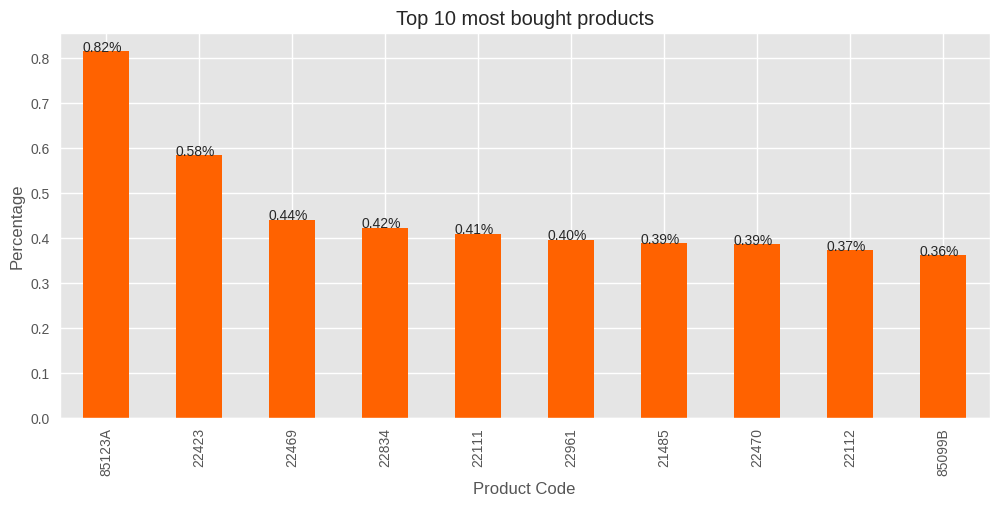

In [ ]:
# Find most ordering products
top10_products = data['StockCode'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top10_products.plot(kind='bar', color='#ff6200')

for index, value in enumerate(top10_products):
    plt.text(index-0.25, value, f'{value:.2f}%', fontsize=10)

plt.title("Top 10 most bought products")
plt.xlabel("Product Code")
plt.ylabel("Percentage")

In [ ]:
len(data.StockCode.unique())

# There are different types of products that can lead to distinct group of customers

2570

In [ ]:
# take a look on popular item
data[data.StockCode == '85123A'].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed


In [ ]:
data['StockCode_len'] = data['StockCode'].astype(str).str.len()
data.StockCode_len.value_counts()

,count
StockCode_len,
5,33472
6,4195
4,113
1,49
7,44
2,12
12,2


In [ ]:
data[(data['StockCode_len'] < 5) | (data['StockCode_len'] > 7)]
data[(data['StockCode_len'] > 8)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len
4406,536779,BANK CHARGES,Bank Charges,1,12/2/2010 15:08,15.0,15823.0,United Kingdom,Completed,12
62508,541505,BANK CHARGES,Bank Charges,1,1/18/2011 15:58,15.0,15939.0,United Kingdom,Completed,12


In [ ]:
# Traditional loop coding
# s = pd.Series(unique_stock_code)
# count_digit = []
# for x in s:
#     n = 0
#     for c in str(x):
#         if c.isdigit():
#             n += 1
#     count_digit.append(n)
# pd.DataFrame(count_digit).value_counts().rename_axis('Value').reset_index(name = 'Count')

unique_stock_code = data.StockCode.unique()
pd.Series(unique_stock_code).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

,count
5,2565
0,4
1,1


In [ ]:
# Ident ify stock code with 0 or 1 digit

abnormal_stock_code = [code for code in unique_stock_code if sum(c.isdigit() for c in str(code)) in (0,1)]
abnormal_stock_code

['POST', 'D', 'C2', 'M', 'BANK CHARGES']

In [ ]:
# Traditional loop coding
# for n in unique_stock_code:
#     cnt = 0
#     for c in str(n):
#         if c.isdigit():
#             cnt +=1
#     if cnt in (0,1):
#         print(n)

abnomal_codes = [code for code in unique_stock_code
                 if sum(c.isdigit() for c in str(code)) in (0,1)]
abnomal_codes

['POST', 'D', 'C2', 'M', 'BANK CHARGES']

In [ ]:
# find the percentage of these code in data
print(f"Percentage of abnomal transactions is {data['StockCode'].isin(abnomal_codes).sum()/ data.shape[0] * 100: .2f} %")

# we will remove them

Percentage of abnomal transactions is  0.46 %


In [ ]:
# Remove abnomal StockCode
data = data[data['StockCode'].isin(abnormal_stock_code) == False]
data.shape[0]

37711

## 3.5 Handling descriptive column

In [ ]:
len(data.Description.unique())

2581

Text(0, 0.5, 'Description')

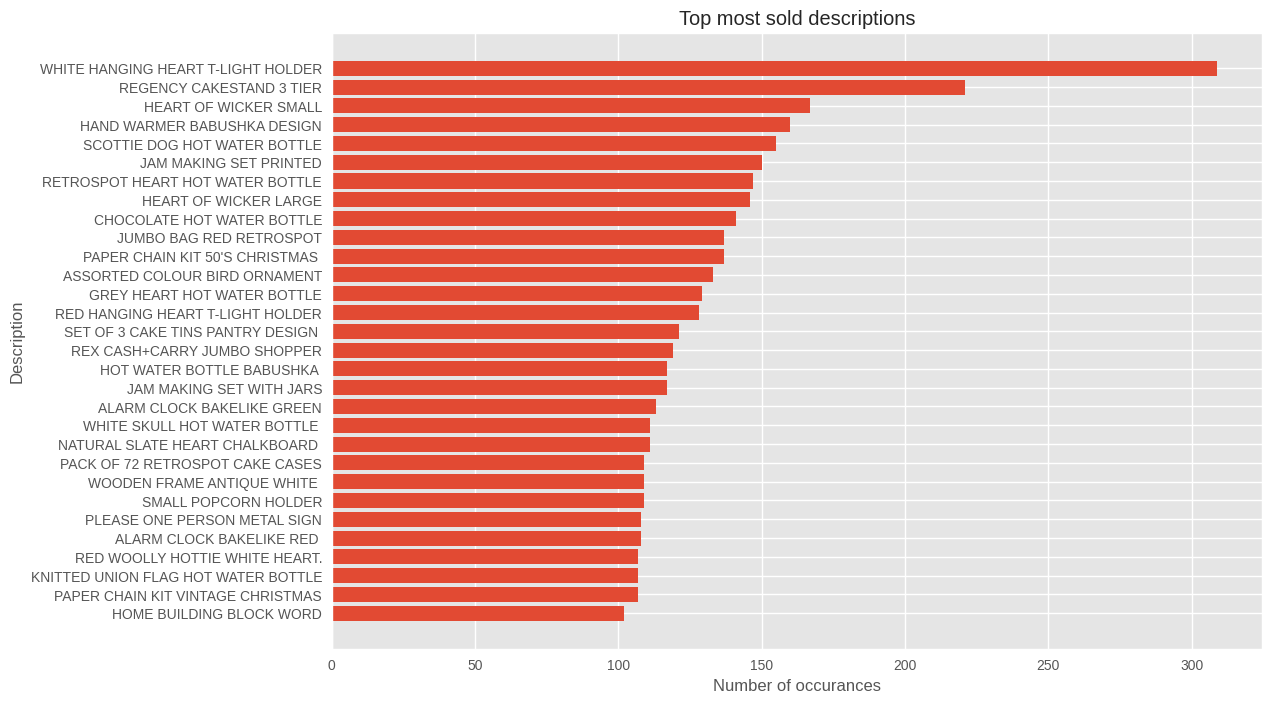

In [ ]:
# count what have been selling well

description_cnt = data.Description.value_counts()
top_description_30 = description_cnt[:30]

plt.figure(figsize = (12,8))
plt.barh(top_description_30.index[::-1], top_description_30[::-1])
plt.title("Top most sold descriptions")
plt.xlabel("Number of occurances")
plt.ylabel("Description")

# finding
# Most items here are in uppercase

In [ ]:
data.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed,6


In [ ]:
# --- let's check if there are anything in lowercase
# lower_case_list = []
# for desc in data.Description:
#     for chr in desc:
#         if chr.islower():
#             lower_case_list.append(desc)
#             break

# for t in lower_case_list:
#     print(t)

list({desc for desc in data.Description if any(chr.islower() for chr in desc)})  # use set instead of list to represent only unique values

['BAG 125g SWIRLY MARBLES',
 'POLYESTER FILLER PAD 40x40cm',
 'FRENCH BLUE METAL DOOR SIGN No',
 'ESSENTIAL BALM 3.5g TIN IN ENVELOPE',
 'POLYESTER FILLER PAD 65CMx65CM',
 'NUMBER TILE VINTAGE FONT No ',
 'POLYESTER FILLER PAD 45x45cm',
 '3 TRADITIONAl BISCUIT CUTTERS  SET',
 'POLYESTER FILLER PAD 45x30cm',
 'FOLK ART GREETING CARD,pack/12',
 'POLYESTER FILLER PAD 30CMx30CM',
 'BAG 500g SWIRLY MARBLES',
 'NUMBER TILE COTTAGE GARDEN No',
 'BAG 250g SWIRLY MARBLES']

In [ ]:
data[data.Description.isin(['High Resolution Image', 'Next Day Carriage'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len


In [ ]:
# take the rows with two description off

service_ralated = ['High Resolution Image', 'Next Day Carriage']

# How much of these type
p = np.shape(data[data.Description.isin(['High Resolution Image', 'Next Day Carriage'])])[0]/ np.shape(data)[0] * 100
print(f"percentage of them is {p:.2f}%")

# get rid of them
data = data[~data.Description.isin(service_ralated)]
print(f"They are {data.shape} rows left")

data.Description = data.Description.str.upper()
data

percentage of them is 0.00%
They are (37711, 10) rows left


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed,6
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed,5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Completed,6
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed,6
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed,6
...,...,...,...,...,...,...,...,...,...,...
62503,541504,21928,JUMBO BAG SCANDINAVIAN PAISLEY,3,1/18/2011 15:37,1.95,14415.0,United Kingdom,Completed,5
62504,541504,22690,DOORMAT HOME SWEET HOME BLUE,2,1/18/2011 15:37,7.95,14415.0,United Kingdom,Completed,5
62505,541504,20685,DOORMAT RED RETROSPOT,1,1/18/2011 15:37,7.95,14415.0,United Kingdom,Completed,5
62506,541504,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,3,1/18/2011 15:37,2.95,14415.0,United Kingdom,Completed,5


In [ ]:
list({desc for desc in data.Description if any(chr.islower() for chr in desc)})  # use set instead of list to represent only unique values

[]

# Zero unite price

In [ ]:
data.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed,6


In [ ]:
data.UnitPrice.describe()

,UnitPrice
count,37711.000000
mean,3.132994
std,5.598214
min,0.000000
25%,1.250000
50%,2.100000
75%,3.750000
max,295.000000


<Axes: xlabel='UnitPrice'>

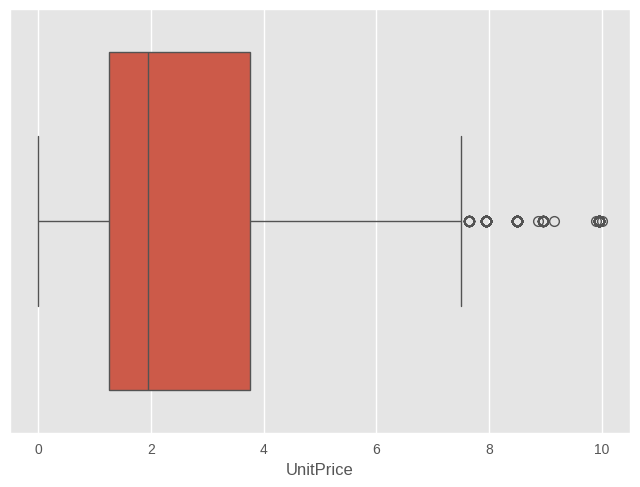

In [ ]:
sns.boxplot(x = data[data.UnitPrice <= 10].UnitPrice)

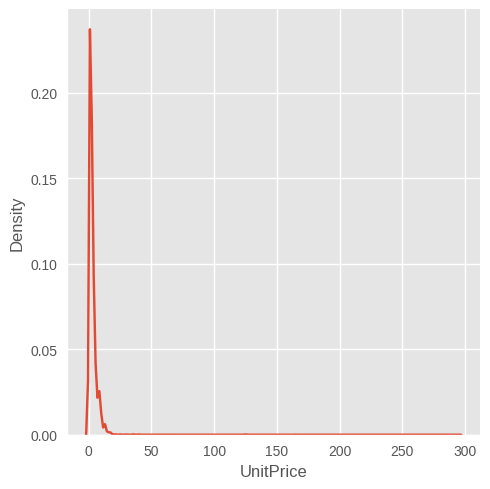

In [ ]:
sns.displot(data, x="UnitPrice",  kind="kde")

In [ ]:

data[data.UnitPrice == 0].Quantity.describe()

,Quantity
count,6.000000
mean,10.666667
std,10.838204
min,1.000000
25%,1.750000
50%,7.000000
75%,20.500000
max,24.000000


In [ ]:
data = data[~(data.UnitPrice == 0)]
data.shape

(37705, 10)

# Outliers

do it after feature engineering phase

In [ ]:
# resetting index of the cleaned data

data.reset_index(drop = True, inplace = True)
data.shape

(37705, 10)

# Feature Engineering
create customer-centric dataset

## 1 RFM

### 1.1 Recency ==> R
How long from the lastest time each customer made a purchase. This value indicates higher engagement with the brand

In [ ]:
# convert InvoiceData to datetime type (check result after chainging, you cannot see the changed datatype)
data.InvoiceDate = pd.to_datetime(data.InvoiceDate)

# get only the date
data['InvoiceDay'] = data['InvoiceDate'].dt.date

# find the most recent purchase
customer_data = data.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# find the present day --> in the real situation, you might be able to use TODAY as the present day
present_day = data.InvoiceDay.max()

# make sure you convert both "day" and "present_day" to datetime format
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
present_day = pd.to_datetime(present_day)

# calculate number of days from the last purchase
customer_data['Days_from_lastPurchase'] = (present_day - customer_data['InvoiceDay']).dt.days

# remove InvoiceDay column to make dataset looks nicer
customer_data.drop(columns = 'InvoiceDay', inplace = True)

### 1.2 Frequency (F)

2.1 Frequency to come in (number of transactions) <br>
2.2 Frequency in term of purchased items (number of products brought)

In [ ]:
customer_data.head()

,CustomerID,Days_from_lastPurchase
0,12346.0,0
1,12347.0,42
2,12348.0,33
3,12356.0,0
4,12359.0,6


In [ ]:
# Note that products that were cancelled will be even out with the product purchased
data[data.CustomerID == 12346 ]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len,InvoiceDay
37334,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,Completed,5,2011-01-18
37339,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,Cancelled,5,2011-01-18


In [ ]:
# Total transactions
total_transactions = data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns = {'InvoiceNo' : 'Total_transaction'}, inplace = True)

# Total products
total_products = data.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products.rename(columns = {'Quantity' : 'Total_product'}, inplace = True)

# Merge
customer_data = pd.merge(customer_data, total_transactions, on = 'CustomerID')
customer_data = pd.merge(customer_data, total_products, on = 'CustomerID')

### 1.3 Monetary (M)
3.1 Total spend -  total money spent by each customer which indicates "customer's value" to the business <br>
3.2 Average transaction value -- usefule in understanding the spending behaviour of customer per transaction -- can be used to tailoring marketing strategies to different customer segments

In [ ]:
data['Total_spend'] = data['Quantity'] * data['UnitPrice']
cust_spend = data.groupby('CustomerID')['Total_spend'].sum().reset_index()
customer_data = pd.merge(customer_data, cust_spend, on = 'CustomerID')
customer_data['Avg_transaction_value'] = customer_data['Total_spend'] / customer_data['Total_transaction']

In [ ]:
customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value
0,12346.0,0,2,0,0.00,0.00
1,12347.0,42,1,319,711.79,711.79
2,12348.0,33,1,1248,652.80,652.80
3,12356.0,0,1,1198,1947.62,1947.62
4,12359.0,6,1,144,547.50,547.50


## 2. Product diversity

In [ ]:
customer_data.head(2)

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value
0,12346.0,0,2,0,0.00,0.00
1,12347.0,42,1,319,711.79,711.79


In [ ]:
data.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len,InvoiceDay,Total_spend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Completed,6,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Completed,5,2010-12-01,20.34


In [ ]:
unique_product = data.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_product.rename(columns = {'StockCode': 'Unique_product'}, inplace = True)
customer_data = pd.merge(customer_data, unique_product, on = 'CustomerID')

## 3. Behavioral features
1. Average number of days between each purchase <br>
2. Favorite shopping day of week <br>
3. Faborite shopping time of day

In [ ]:
customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product
0,12346.0,0,2,0,0.00,0.00,1
1,12347.0,42,1,319,711.79,711.79,31
2,12348.0,33,1,1248,652.80,652.80,12
3,12356.0,0,1,1198,1947.62,1947.62,35
4,12359.0,6,1,144,547.50,547.50,16


In [ ]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_status,StockCode_len,InvoiceDay,Total_spend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Completed,6,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Completed,5,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Completed,6,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Completed,6,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Completed,6,2010-12-01,20.34


In [ ]:
# extract day and hour (time) of each shopping
data['Day_of_week'] = data['InvoiceDate'].dt.dayofweek   # Day of week starts from Monday which indicated by 0!
data['Hour'] = data['InvoiceDate'].dt.hour

# average number of days between each shopping
days_btw_purchases = data.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
avg_days_btw_purchases = days_btw_purchases.groupby('CustomerID').mean().reset_index()
avg_days_btw_purchases.rename(columns = {'InvoiceDay': 'avg_days_btw_purchases'}, inplace = True)

# favorite shopping day of week
favorite_shopping_day = data.groupby(['CustomerID', 'Day_of_week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_of_week']]

# favorite shopping hour of day
favorite_shopping_hour = data.groupby(['CustomerID', 'Hour']).size().reset_index(name = 'Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]

# merge data
customer_data = pd.merge(customer_data, avg_days_btw_purchases, on = 'CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on = 'CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on = 'CustomerID')

customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour
0,12346.0,0,2,0,0.00,0.00,1,0.0,1,10
1,12347.0,42,1,319,711.79,711.79,31,0.0,1,14
2,12348.0,33,1,1248,652.80,652.80,12,0.0,3,19
3,12356.0,0,1,1198,1947.62,1947.62,35,0.0,1,9
4,12359.0,6,1,144,547.50,547.50,16,0.0,2,12


# Geographic

In [ ]:
print(data['Country'].value_counts(normalize = True).head())
data['Country'].value_counts()[0]/data.shape[0]

# There is 89% of customer come from the UK -- very imbalance data
# Set flg feature for UK and Non-UK

Country
United Kingdom    0.899456
Germany           0.024824
France            0.021960
EIRE              0.011431
Spain             0.008646
Name: proportion, dtype: float64


np.float64(0.8994563055297706)

In [ ]:
# Group by CustomerID and Country to get the number of transactions per country for each customer

customer_country = data.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')

In [ ]:
# each customer can make an order from different countries

customer_country['CustomerID'].duplicated().any()
customer_country[customer_country['CustomerID'].duplicated(keep=False)]

,CustomerID,Country,Number_of_Transactions
5,12370.0,Austria,7
6,12370.0,Cyprus,82


In [ ]:
# Identify the main country (a country with maximum transaction) to each customer and drop the others
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending = False).drop_duplicates('CustomerID')

# Create a binary column for whether they are a UK-based customer
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Merge this data with our customer data
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID','Is_UK']], on = 'CustomerID', how = 'left')

customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK
0,12346.0,0,2,0,0.00,0.00,1,0.0,1,10,1
1,12347.0,42,1,319,711.79,711.79,31,0.0,1,14,0
2,12348.0,33,1,1248,652.80,652.80,12,0.0,3,19,0
3,12356.0,0,1,1198,1947.62,1947.62,35,0.0,1,9,0
4,12359.0,6,1,144,547.50,547.50,16,0.0,2,12,0


In [ ]:
# Customer distribution
customer_data['Is_UK'].value_counts()

,count
Is_UK,
1,1006
0,105


# Cancellation Insights

In [ ]:
# find out number of all transations and the cancelled transaction. Therefore, we calculate cancellation frequency and rate

total_transaction = data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

cancelled_data = data[data['Transaction_status'] == 'Cancelled']
cancelled_transaction = cancelled_data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()  # we got frequency of transaction here
cancelled_transaction.rename(columns = {'InvoiceNo' : 'Cancelled_frequency'}, inplace = True)

# mearg the frequency to customer_data
customer_data = pd.merge(customer_data, cancelled_transaction, on = 'CustomerID', how = 'left')
customer_data['Cancelled_frequency'].fillna(0, inplace = True)

# calculate cancellation rate
customer_data['Cancelled_rate'] = customer_data['Cancelled_frequency']/customer_data['Total_transaction']

# Seasonality and Trends

In [ ]:
# Extract Year and month
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month

# data.groupby(['Year', 'Month']).count()
monthly_spend = data.groupby(['CustomerID', 'Year', 'Month'])['Total_spend'].sum().reset_index()

# Seasonal buying patterns from the monthly_spend
season_pattern = monthly_spend.groupby('CustomerID')['Total_spend'].agg(['mean', 'std']).reset_index()
season_pattern.rename(columns = {'mean': 'Monthly_spend_mean',
                                 'std' : 'Monthly_spend_std'}, inplace = True)
season_pattern.Monthly_spend_std.fillna(0, inplace = True)

# calculate trends in spending --> use linear regression
def trend_cal(data):
    if len(data) > 1:
        x = np.arange(len(data))
        slope, _, _, _, _ = linregress(x, data)
        return slope
    else:
        return 0

trend_spend = monthly_spend.groupby('CustomerID')['Total_spend'].apply(trend_cal).reset_index()
trend_spend.rename(columns = {'Total_spend' : 'Trend_spend'}, inplace = True)

# merge these colums to the customer_data
customer_data = pd.merge(customer_data, season_pattern, on = 'CustomerID')
customer_data = pd.merge(customer_data, trend_spend, on = 'CustomerID')

customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK,Cancelled_frequency,Cancelled_rate,Monthly_spend_mean,Monthly_spend_std,Trend_spend
0,12346.0,0,2,0,0.00,0.00,1,0.0,1,10,1,1.0,0.5,0.00,0.0,0.0
1,12347.0,42,1,319,711.79,711.79,31,0.0,1,14,0,0.0,0.0,711.79,0.0,0.0
2,12348.0,33,1,1248,652.80,652.80,12,0.0,3,19,0,0.0,0.0,652.80,0.0,0.0
3,12356.0,0,1,1198,1947.62,1947.62,35,0.0,1,9,0,0.0,0.0,1947.62,0.0,0.0
4,12359.0,6,1,144,547.50,547.50,16,0.0,2,12,0,0.0,0.0,547.50,0.0,0.0


In [ ]:
customer_data.head(10)

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK,Cancelled_frequency,Cancelled_rate,Monthly_spend_mean,Monthly_spend_std,Trend_spend
0,12346.0,0,2,0,0.00,0.000,1,0.000000,1,10,1,1.0,0.5,0.00,0.000000,0.00
1,12347.0,42,1,319,711.79,711.790,31,0.000000,1,14,0,0.0,0.0,711.79,0.000000,0.00
2,12348.0,33,1,1248,652.80,652.800,12,0.000000,3,19,0,0.0,0.0,652.80,0.000000,0.00
3,12356.0,0,1,1198,1947.62,1947.620,35,0.000000,1,9,0,0.0,0.0,1947.62,0.000000,0.00
4,12359.0,6,1,144,547.50,547.500,16,0.000000,2,12,0,0.0,0.0,547.50,0.000000,0.00
5,12370.0,32,2,964,1744.27,872.135,89,0.034091,1,12,0,0.0,0.0,1744.27,0.000000,0.00
6,12377.0,29,1,604,1001.52,1001.520,43,0.000000,0,9,0,0.0,0.0,1001.52,0.000000,0.00
7,12383.0,6,2,1337,1146.88,573.440,61,0.323077,2,14,0,0.0,0.0,573.44,25.059864,35.44
8,12386.0,12,2,354,401.90,200.950,10,3.222222,2,9,0,0.0,0.0,200.95,81.953676,-115.90
9,12388.0,1,1,204,431.30,431.300,19,0.000000,0,11,0,0.0,0.0,431.30,0.000000,0.00


# Hooray! We have done creting a customer dataset

In [ ]:
# change data type for CustomerID to string, instead of numbers

customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)

# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()

In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111 entries, 0 to 1110
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1111 non-null   string 
 1   Days_from_lastPurchase  1111 non-null   Int64  
 2   Total_transaction       1111 non-null   Int64  
 3   Total_product           1111 non-null   Int64  
 4   Total_spend             1111 non-null   Float64
 5   Avg_transaction_value   1111 non-null   Float64
 6   Unique_product          1111 non-null   Int64  
 7   avg_days_btw_purchases  1111 non-null   Float64
 8   Day_of_week             1111 non-null   Int32  
 9   Hour                    1111 non-null   Int32  
 10  Is_UK                   1111 non-null   Int64  
 11  Cancelled_frequency     1111 non-null   Int64  
 12  Cancelled_rate          1111 non-null   Float64
 13  Monthly_spend_mean      1111 non-null   Float64
 14  Monthly_spend_std       1111 non-null   

# Outlier Detection

In [ ]:
# Create IsolationForest with contamination paremeter 0.05
model = IsolationForest(contamination=0.05, random_state=0)

customer_data['Outlier_scores'] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())
customer_data['Is_outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_scores']]


In [ ]:
customer_data.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK,Cancelled_frequency,Cancelled_rate,Monthly_spend_mean,Monthly_spend_std,Trend_spend,Outlier_scores,Is_outlier
0,12346.0,0,2,0,0.0,0.0,1,0.0,1,10,1,1,0.5,0.0,0.0,0.0,1,0
1,12347.0,42,1,319,711.79,711.79,31,0.0,1,14,0,0,0.0,711.79,0.0,0.0,1,0
2,12348.0,33,1,1248,652.8,652.8,12,0.0,3,19,0,0,0.0,652.8,0.0,0.0,1,0
3,12356.0,0,1,1198,1947.62,1947.62,35,0.0,1,9,0,0,0.0,1947.62,0.0,0.0,-1,1
4,12359.0,6,1,144,547.5,547.5,16,0.0,2,12,0,0,0.0,547.5,0.0,0.0,1,0


In [ ]:
outliers_pct = customer_data['Is_outlier'].value_counts(normalize = True) * 100
outliers_pct

# There are around 5% of outlier. 5% is the reasonable number therefore, isolation forest seems to work well
# strategy: since the nature of our project is the perform customer segmentation, it is crucial to handle outliers.\
# We will separate outliers from the main dataset for the further analysis

,proportion
Is_outlier,
0,94.959496
1,5.040504


In [ ]:
df_outliers = customer_data[customer_data.Is_outlier == 1]

customer_data_cleaned = customer_data[customer_data.Is_outlier == 0]
customer_data_cleaned = customer_data_cleaned.drop(columns = ['Outlier_scores', 'Is_outlier'])
customer_data_cleaned.reset_index(drop = True, inplace = True)

customer_data_cleaned.shape

(1055, 16)

# Correlation analysis

Perfore correlation analysis to prevent multicollinearity, where features are highly correlated, since the highly correlated features can potentially affect the custering performance. The main reason is features do not provide unique information for the model to learn. This could lead to clusters that are not well-separated and meaningful

<Axes: >

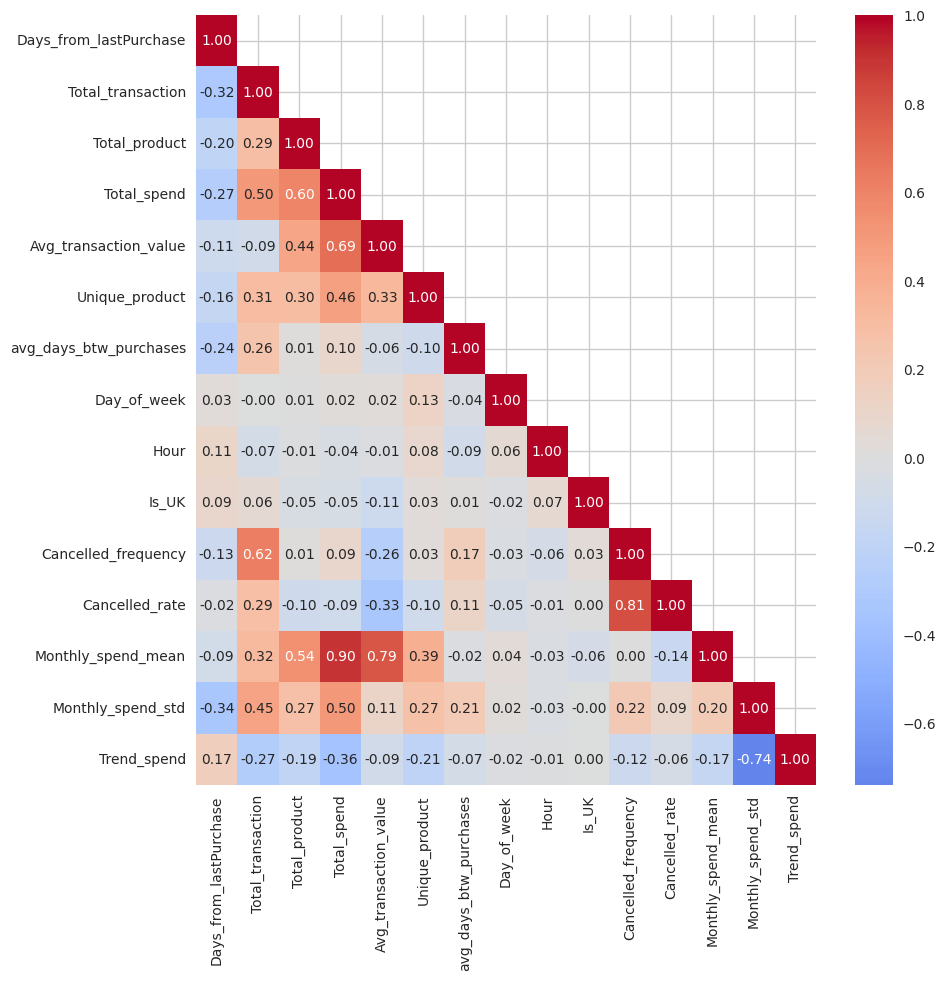

In [ ]:
sns.set_style('whitegrid')
corr = customer_data_cleaned.drop(columns = ['CustomerID']).corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

plt.figure(figsize=(10,10))
sns.heatmap(corr, mask = mask, cmap = 'coolwarm', annot = True, center = 0, fmt = '.2f')

Looking at the heatmap, we can see that there are some pairs of variables that have high correlations, for instance: <br>

Monthly_Spending_Mean and Average_Transaction_Value <br>
Total_Spend and Total_Products_Purchased <br>
Total_Transactions and Total_Spend <br>
Cancellation_Rate and Cancellation_Frequency <br>
Total_Transactions and Total_Products_Purchased <br> <br>
These high correlations indicate that these variables move closely together, implying a degree of multicollinearity.

# Feature Scaling

It is crutial to the distance-based algorithms such as k-mean clustering and dimensionality reduction like PCA (aims to find directions where data varies the most)

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of columns that don't need to be scaled
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']

# List of columns that need to be scaled
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

# Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()

# Applying the scaler to the necessary columns in the dataset
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

# Display the first few rows of the scaled data
customer_data_scaled.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK,Cancelled_frequency,Cancelled_rate,Monthly_spend_mean,Monthly_spend_std,Trend_spend
0,12346.0,-1.616193,0.185560,-0.610088,-0.970970,-1.118435,-1.044660,-0.294296,-0.872398,-1.153923,1,1.232690,1.608045,-1.038295,-0.313081,0.165152
1,12347.0,0.995152,-0.643957,0.155611,0.491001,1.707558,0.148064,-0.294296,-0.872398,0.590187,0,-0.508258,-0.497587,0.869362,-0.313081,0.165152
2,12348.0,0.435578,-0.643957,2.385498,0.369839,1.473353,-0.607328,-0.294296,0.254138,2.770325,0,-0.508258,-0.497587,0.711264,-0.313081,0.165152
3,12359.0,-1.243144,-0.643957,-0.264444,0.153560,1.055284,-0.448298,-0.294296,-0.309130,-0.281868,0,-0.508258,-0.497587,0.429051,-0.313081,0.165152
4,12370.0,0.373403,0.185560,1.703810,2.611648,2.344170,2.453996,-0.267751,-0.872398,-0.281868,0,-0.508258,-0.497587,3.636496,-0.313081,0.165152


# Dimensionality reduction

In [ ]:
customer_data_scaled.set_index('CustomerID', inplace = True)

# perform PCA and calculate cummulative explained variance for all PCAs
pca_model = PCA().fit(customer_data_scaled)
explained_variance_ratio = pca_model.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
opimal_k = 6

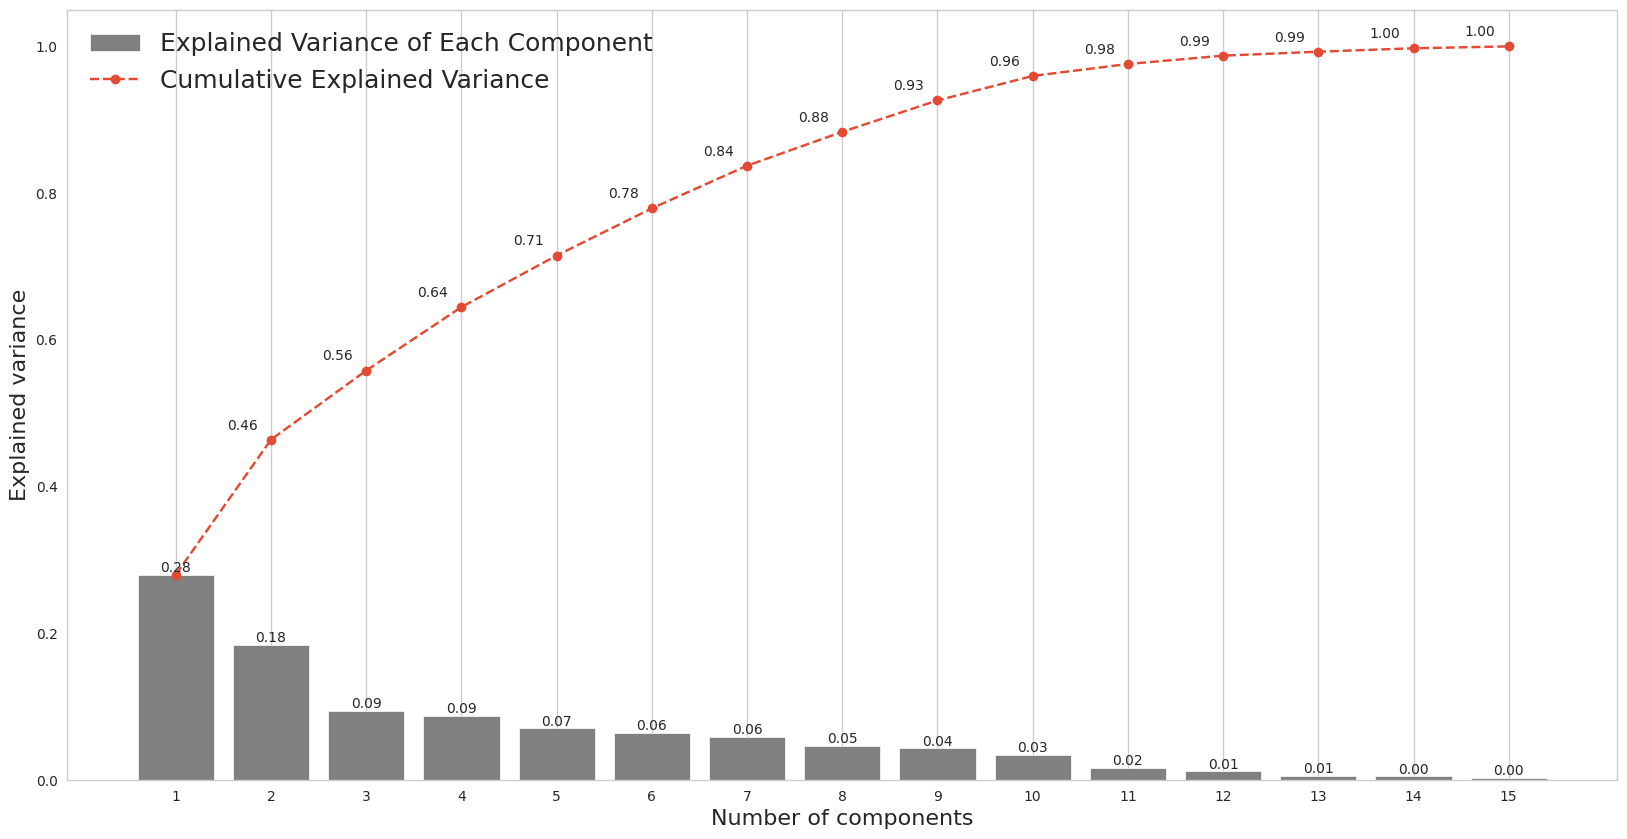

In [ ]:
# Visualization
plt.figure(figsize = (20,10))

# Create barplot
barplot = sns.barplot(x = list(range(1, len(cumulative_explained_variance) +1)),
                      y = explained_variance_ratio,
                      color = 'grey')
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance, linestyle = '--', marker = 'o')

# Ticks and legend
#plt.xticks(range(0, len(cummu_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance'],
           loc= 'best',
           fontsize = 18)

plt.xlabel("Number of components", fontsize = 16)
plt.ylabel("Explained variance", fontsize = 16)

# Display values
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')
plt.show()

# We select the first 6 components which capture approximately 81% of the total variance

In [ ]:
# Create PCA with 6 PCs
pca_cust_model = PCA(n_components= 7)

# Fit and transform data
customer_data_pca = pca_cust_model.fit_transform(customer_data_scaled)

# Create a new dataframe from the PCA result
customer_data_pca = pd.DataFrame(customer_data_pca, columns = ['PC' +str(i+1) for i in range(pca_cust_model.n_components_)])

# Adding CustomerID index back to the dataframe
customer_data_pca.index = customer_data_scaled.index

customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
CustomerID,,,,,,,
12346.0,-1.416714,2.562083,0.184949,-1.248594,-0.310982,-0.570476,-1.144884
12347.0,0.581724,-1.946917,0.737233,-0.034953,-1.155191,0.453119,0.577139
12348.0,1.005257,-2.116192,0.728857,1.127451,-0.441470,2.229093,1.026021
12359.0,0.213608,-1.129292,-0.253231,-1.008675,0.012610,0.052911,-0.423583
12370.0,4.484343,-2.883365,2.147851,-0.455271,-0.699689,0.002576,-0.268332


In [ ]:
# Extract coefficients corresponding to each pc to better understand the transformation of the data
# Define a function to highlight the top 3 absolute values in each column of a dataframe
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color:  #ffeacc' if i in top3 else '' for i in column.index]

pc_df = pd.DataFrame(pca_cust_model.components_.T,
             columns = ['PC {}'.format(i+1) for i in range(pca_cust_model.n_components_)],
             index = customer_data_scaled.columns)

pc_df.style.apply(highlight_top3, axis = 0)

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7
Days_from_lastPurchase,-0.201263,-0.147142,0.273167,0.307327,-0.299230,-0.213879,0.527063
Total_transaction,0.299112,0.359683,0.129396,-0.002785,0.121607,0.058450,-0.150978
Total_product,0.337809,-0.112983,0.123747,-0.063058,-0.034451,0.082176,-0.019704
Total_spend,0.472600,-0.092820,0.111914,-0.051617,-0.036837,0.004845,0.112242
Avg_transaction_value,0.312242,-0.374951,0.147801,-0.120444,-0.044494,0.012144,0.167321
Unique_product,0.286909,-0.076244,0.052580,0.314434,0.159342,-0.017445,-0.511480
avg_days_btw_purchases,0.075786,0.226186,-0.202801,-0.446194,0.311555,0.408724,0.458669
Day_of_week,0.022755,-0.051382,-0.024445,0.412825,0.796164,-0.264354,0.286034
Hour,-0.026121,-0.060856,0.014850,0.551789,-0.080284,0.806632,0.074292
Is_UK,-0.006554,0.009925,0.000032,0.020502,-0.006693,0.014113,-0.001482


# K-mean clustering

In [ ]:
# Identify the suitable number of clusters using Elbow method

km_model = KMeans(init= 'k-means++', n_init= 10, max_iter = 100, random_state= 0)


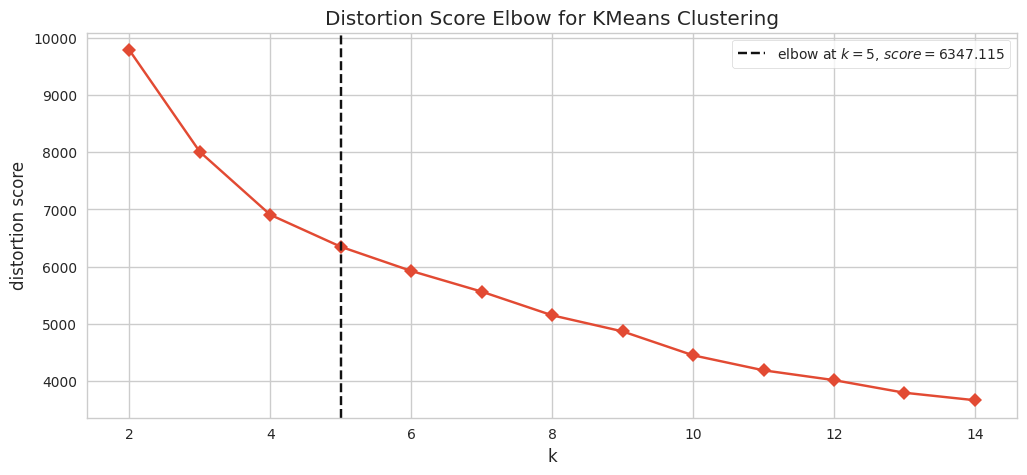

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
fig, ax = plt.subplots(figsize = (12,5))
visual_model = KElbowVisualizer(km_model, k = (2, 15), timings = False, ax = ax)
visual_model.fit(customer_data_pca)
visual_model.show()

In [ ]:
def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):
    """
    Perform Silhouette analysis for a range of k values and visualize the results.
    """

    # Set the size of the figure
    plt.figure(figsize=figsize)

    # Create a grid with (stop_k - start_k + 1) rows and 2 columns
    grid = gridspec.GridSpec(stop_k - start_k + 1, 2)

    # Assign the first plot to the first row and both columns
    first_plot = plt.subplot(grid[0, :])

    # First plot: Silhouette scores for different k values
    sns.set_palette(['darkorange'])

    silhouette_scores = []

    # Iterate through the range of k values
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        km.fit(df)
        labels = km.predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + silhouette_scores.index(max(silhouette_scores))

    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xticks(range(start_k, stop_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Average Silhouette Score for Different k Values', fontsize=15)

    # Add the optimal k value text to the plot
    optimal_k_text = f'The k value with the highest Silhouette score is: {best_k}'
    plt.text(10, 0.23, optimal_k_text, fontsize=12, verticalalignment='bottom',
             horizontalalignment='left', bbox=dict(facecolor='#fcc36d', edgecolor='#ff6200', boxstyle='round, pad=0.5'))


    # Second plot (subplot): Silhouette plots for each k value
    colors = sns.color_palette("bright")

    for i in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=0)
        row_idx, col_idx = divmod(i - start_k, 2)

        # Assign the plots to the second, third, and fourth rows
        ax = plt.subplot(grid[row_idx + 1, col_idx])

        visualizer = SilhouetteVisualizer(km, colors=colors, ax=ax)
        visualizer.fit(df)

        # Add the Silhouette score text to the plot
        score = silhouette_score(df, km.labels_)
        ax.text(0.97, 0.02, f'Silhouette Score: {score:.2f}', fontsize=12, \
                ha='right', transform=ax.transAxes, color='red')

        ax.set_title(f'Silhouette Plot for {i} Clusters', fontsize=15)

    plt.tight_layout()
    plt.show()

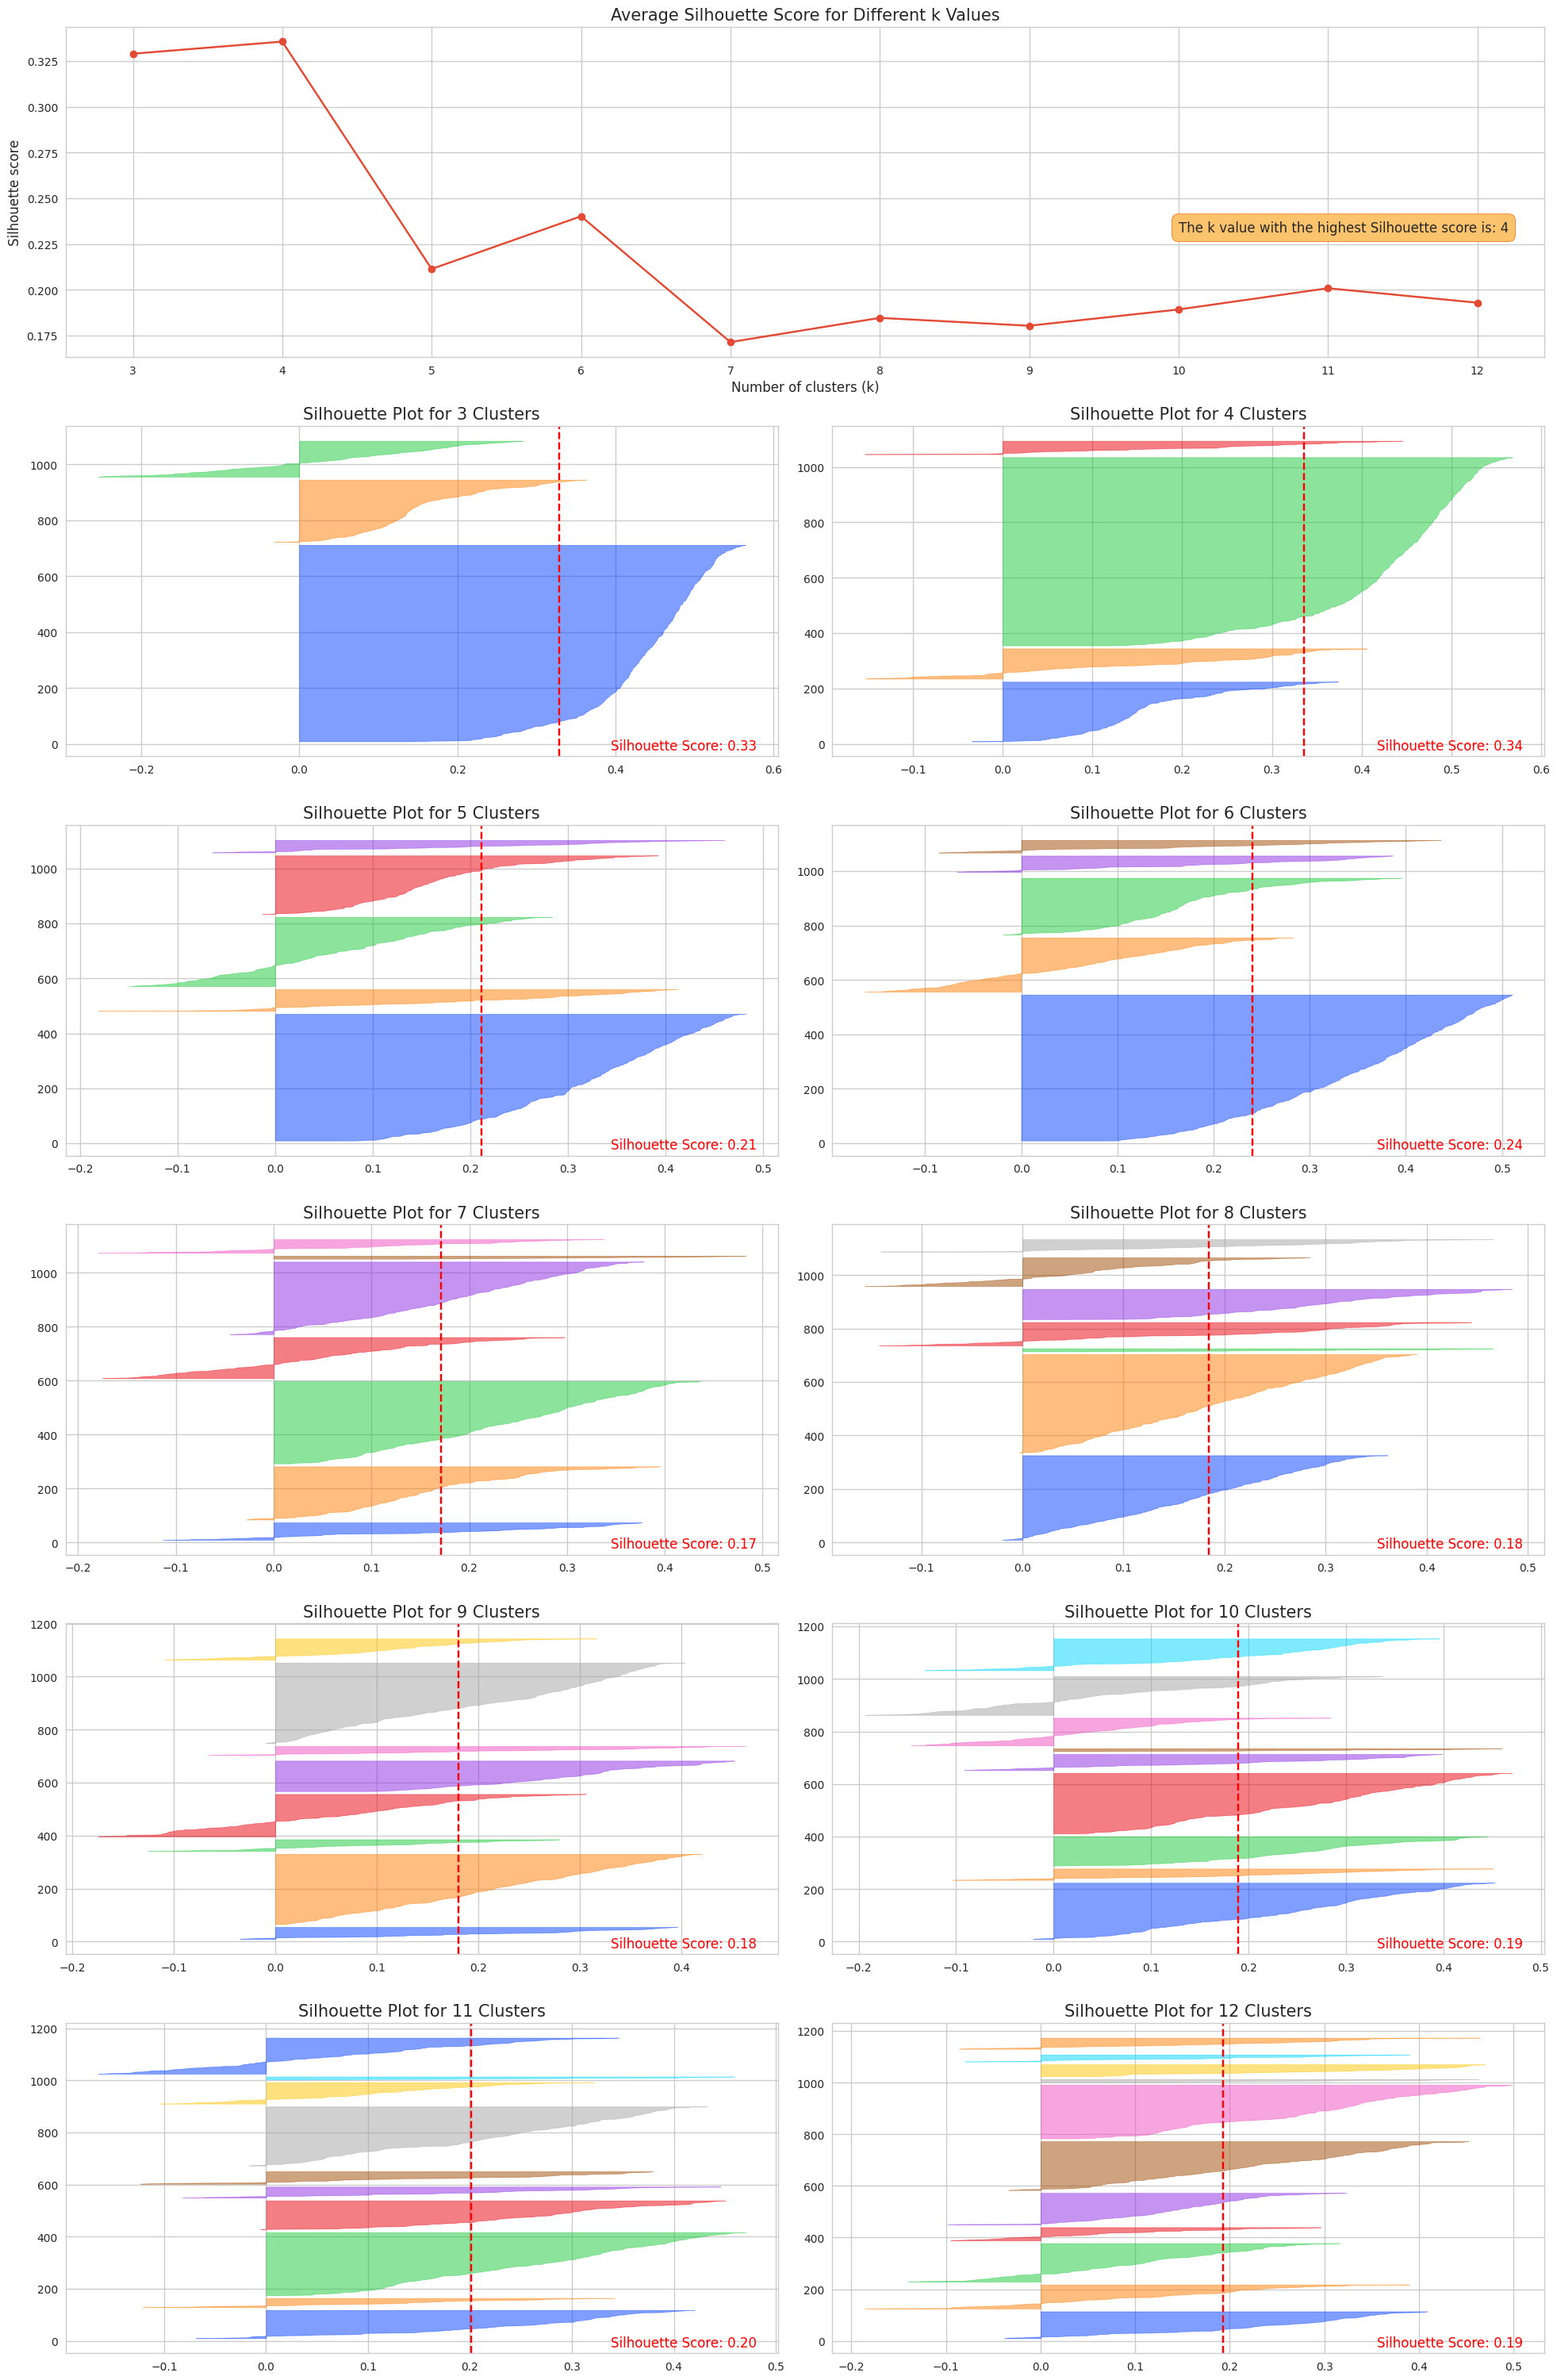

In [ ]:
silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

# K-mean clustering

In [ ]:
kmean_model = KMeans(n_clusters= 3, init = 'k-means++', n_init = 10, max_iter = 100, random_state = 0)
kmean_model.fit(customer_data_pca)

cluster_freq = Counter(kmean_model.labels_)

label_mapping = {label: new_label for new_label, (label, _) in
                 enumerate(cluster_freq.most_common())}

new_labels = np.array([label_mapping[label] for label in kmean_model.labels_])
customer_data_cleaned['Label'] = new_labels
customer_data_pca['Label'] = new_labels

In [ ]:
customer_data_cleaned.head()

,CustomerID,Days_from_lastPurchase,Total_transaction,Total_product,Total_spend,Avg_transaction_value,Unique_product,avg_days_btw_purchases,Day_of_week,Hour,Is_UK,Cancelled_frequency,Cancelled_rate,Monthly_spend_mean,Monthly_spend_std,Trend_spend,Label
0,12346.0,0,2,0,0.0,0.0,1,0.0,1,10,1,1,0.5,0.0,0.0,0.0,1
1,12347.0,42,1,319,711.79,711.79,31,0.0,1,14,0,0,0.0,711.79,0.0,0.0,0
2,12348.0,33,1,1248,652.8,652.8,12,0.0,3,19,0,0,0.0,652.8,0.0,0.0,0
3,12359.0,6,1,144,547.5,547.5,16,0.0,2,12,0,0,0.0,547.5,0.0,0.0,0
4,12370.0,32,2,964,1744.27,872.135,89,0.034091,1,12,0,0,0.0,1744.27,0.0,0.0,2


# Clustering Evaluation

In [ ]:
# Create separate data frames for each cluster

colors = ['#e8000b', '#1ac938', '#023eff']
cluster_0 = customer_data_pca[customer_data_pca['Label'] == 0]
cluster_1 = customer_data_pca[customer_data_pca['Label'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['Label'] == 2]

# Create a 3D scatter plot
fig = go.Figure()

# Add data points for each cluster separately and specify the color
fig.add_trace(go.Scatter3d(x=cluster_0['PC1'], y=cluster_0['PC2'], z=cluster_0['PC3'],
                           mode='markers', marker=dict(color=colors[0], size=5, opacity=0.4), name='Cluster 0'))
fig.add_trace(go.Scatter3d(x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'],
                           mode='markers', marker=dict(color=colors[1], size=5, opacity=0.4), name='Cluster 1'))
fig.add_trace(go.Scatter3d(x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'],
                           mode='markers', marker=dict(color=colors[2], size=5, opacity=0.4), name='Cluster 2'))

# Set the title and layout details
fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters in PCA Space', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)

# Show the plot
fig.show()


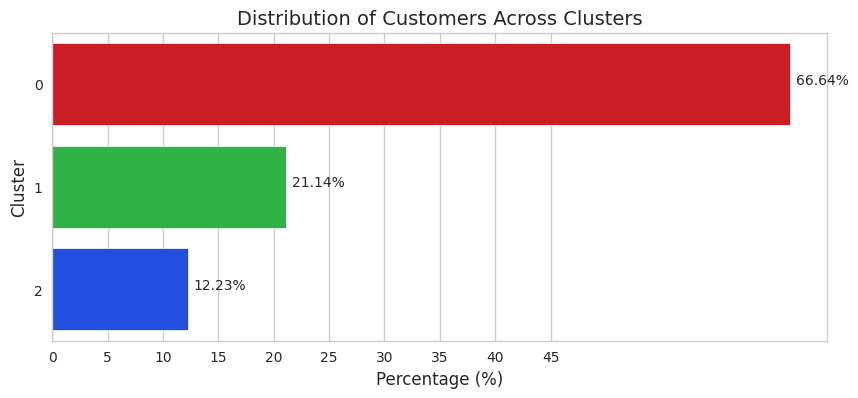

In [ ]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['Label'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors)

# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xticks(ticks=np.arange(0, 50, 5))
plt.xlabel('Percentage (%)')

# Show the plot
plt.show()


In [ ]:
# Evaluation Metric
# Compute number of customers
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('Label', axis=1)
clusters = customer_data_pca['Label']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]

# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

# In conclusion, the metrics suggest that the clustering is of good quality,
# with clusters being well-defined and fairly separated. However, there might still be room for further optimization to enhance cluster separation
# and definition, potentially by trying other clustering and dimensionality reduction algorithms.

+-------------------------+--------------------+
|         Metric          |       Value        |
+-------------------------+--------------------+
| Number of Observations  |        1055        |
|    Silhouette Score     | 0.3289802713344987 |
| Calinski Harabasz Score |  291.138145453435  |
|  Davies Bouldin Score   | 1.3791023777259224 |
+-------------------------+--------------------+


In [ ]:
customer_data_cleaned['Label'].value_counts()

,count
Label,
0,703
1,223
2,129


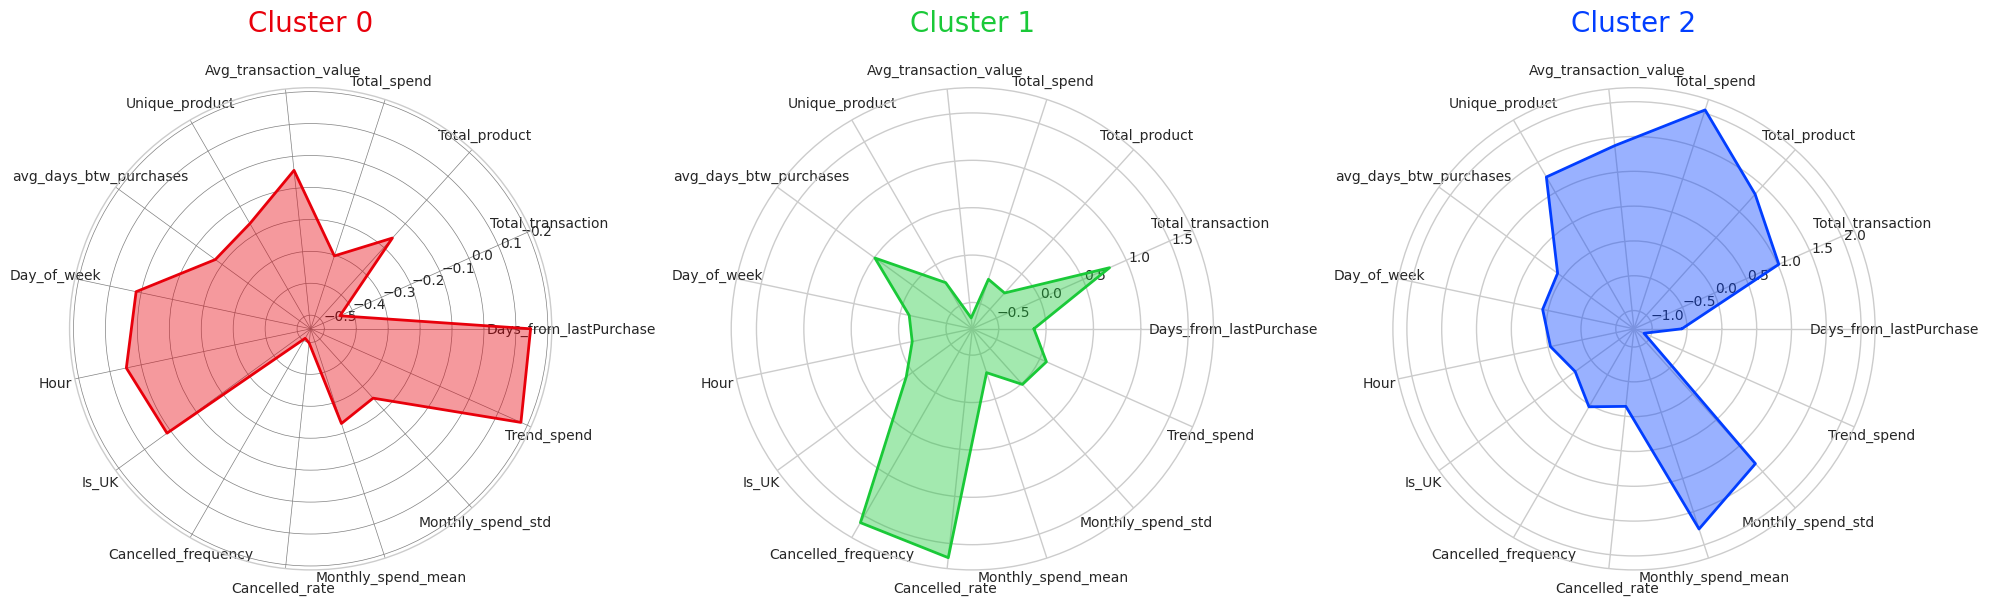

In [ ]:
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('CustomerID')

# Standardize the data (excluding the cluster column)
scaler = StandardScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['Label'], axis=1))

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['Label']

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels=np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data_redar = cluster_centroids.loc[i].tolist()
    data_redar += data_redar[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data_redar, color, i)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

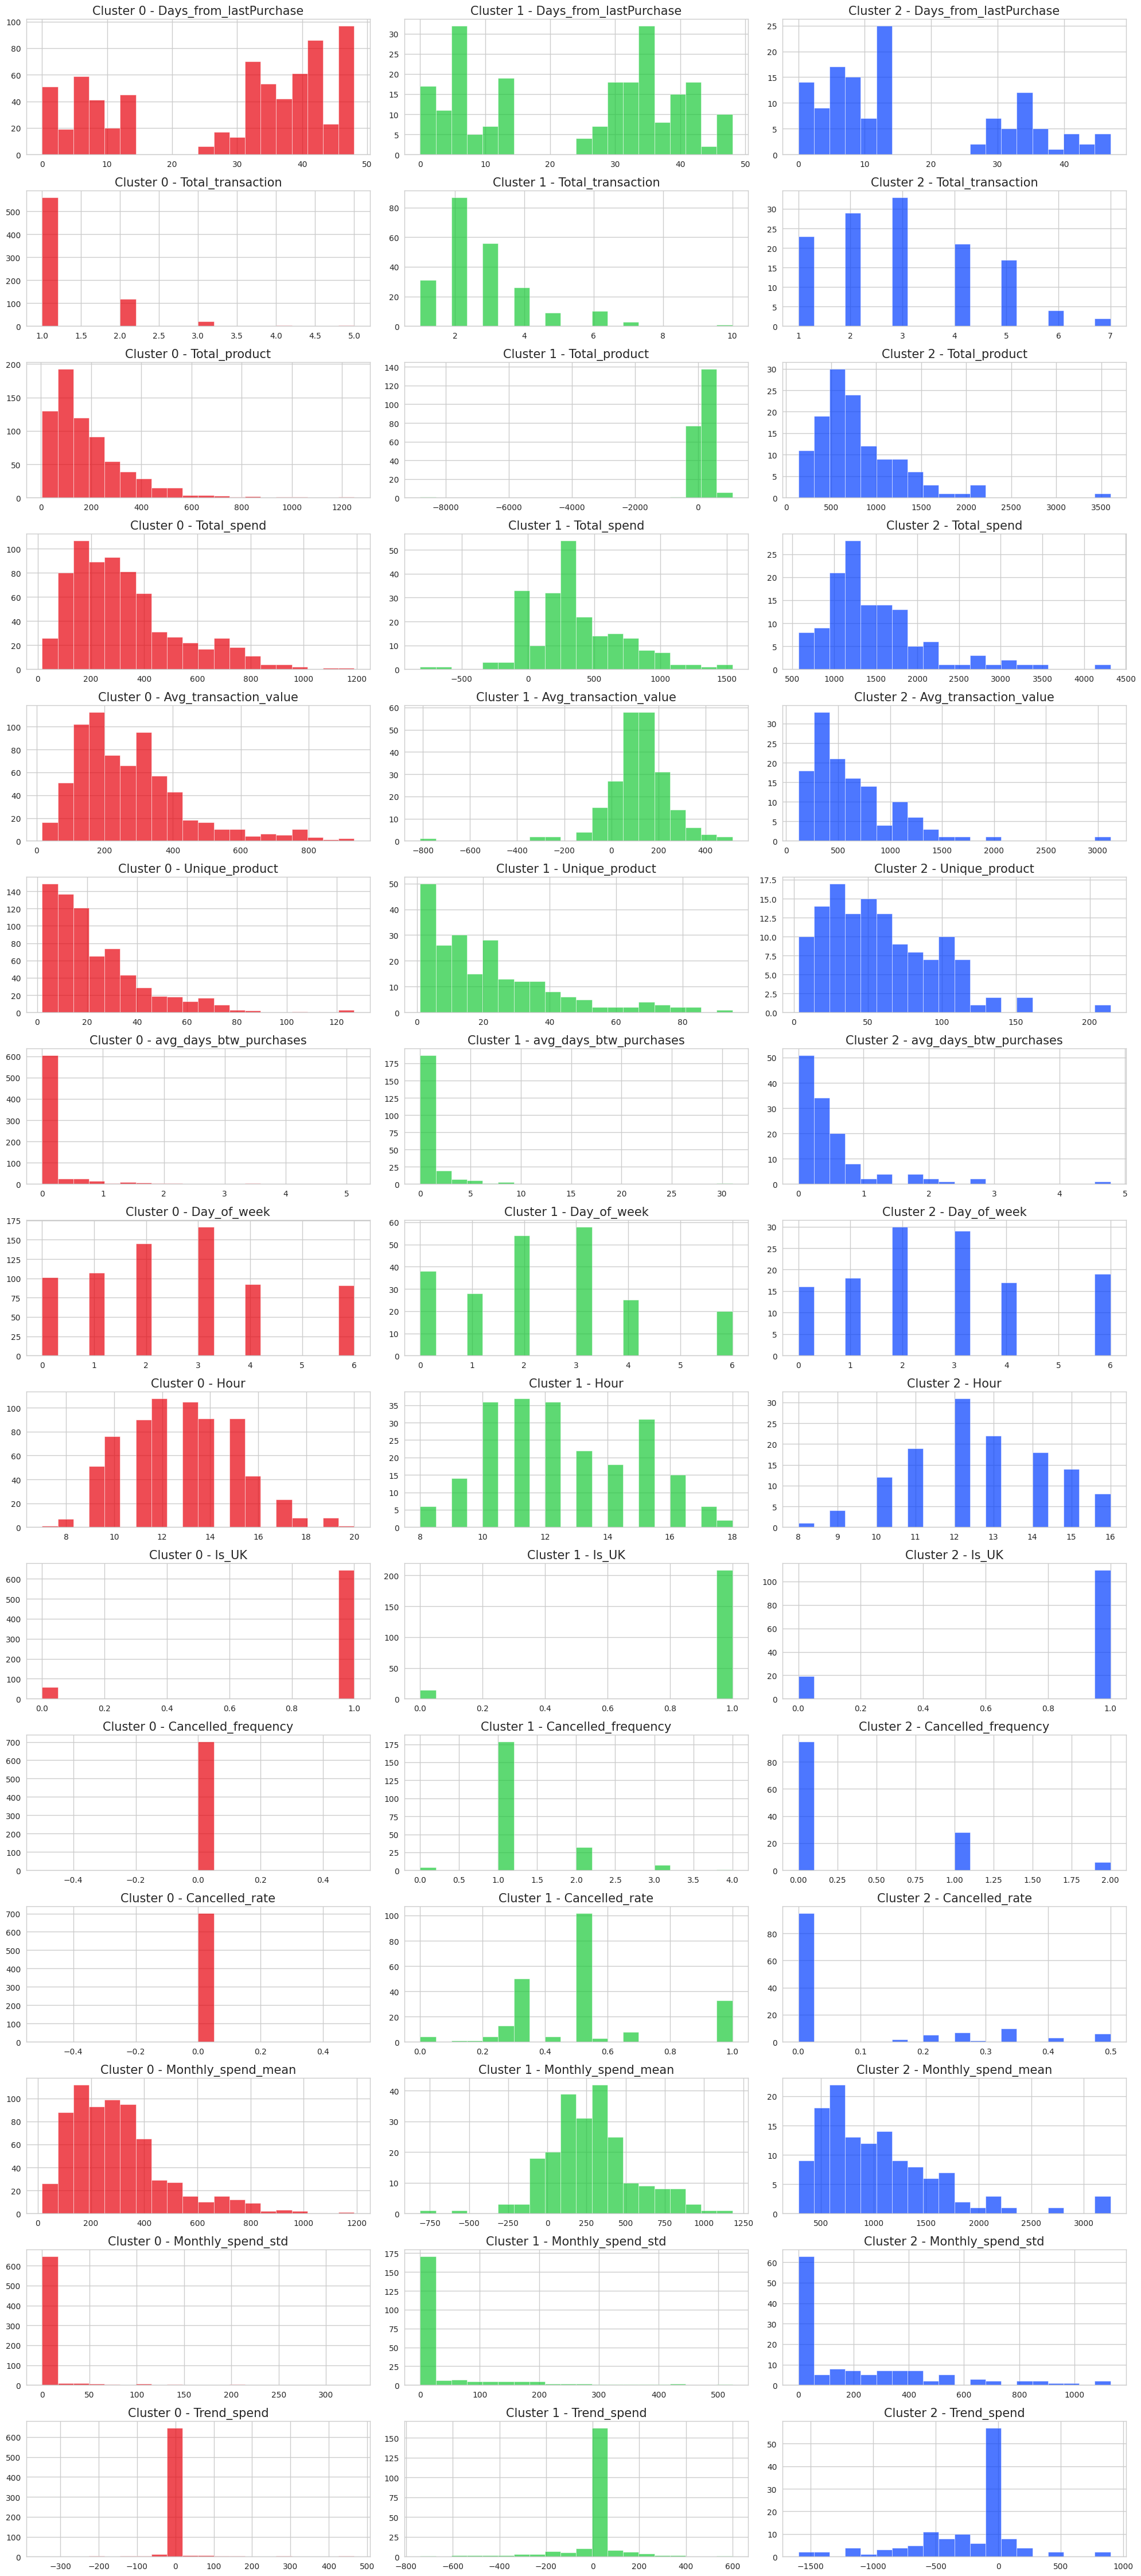

In [ ]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['Label'].unique()
clusters.sort()

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data_hist = customer_data_cleaned[customer_data_cleaned['Label'] == cluster][feature]
        axes[i, j].hist(data_hist, bins=20, color=colors[j], edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

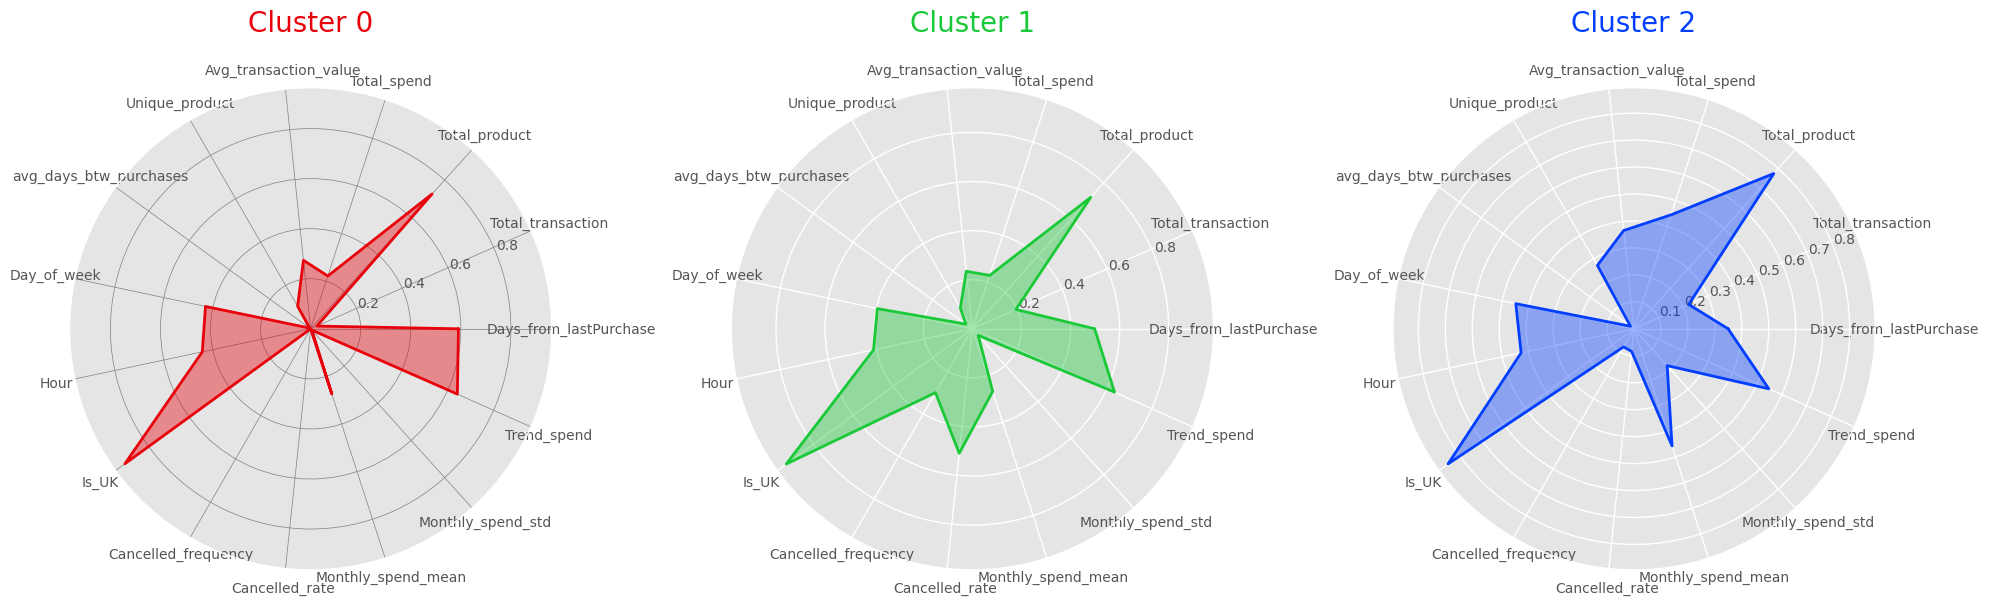

In [ ]:
# Optional: Min-max scaling to compare radar of each cluster
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('CustomerID')


# Standardize the data (excluding the cluster column)
scaler = MinMaxScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['Label'], axis=1))

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['Label']

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels=np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data_redar = cluster_centroids.loc[i].tolist()
    data_redar += data_redar[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data_redar, color, i)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()